In [1]:
import pandas as pd
import numpy as np
import streamlit as st

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# pip install kaggle 
# pip install kagglehub
#run this above command if the kaggle is not installed on your machine

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/human-activity-recognition-with-smartphones")

print("Path to dataset files:", path)

Path to dataset files: /Users/I325715/.cache/kagglehub/datasets/uciml/human-activity-recognition-with-smartphones/versions/2


In [4]:
df=pd.read_csv(path+"/train.csv")
df_test=pd.read_csv(path+"/test.csv")


In [5]:
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [6]:
df_test.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING


In [7]:
df.shape

(7352, 563)

In [8]:
df_test.shape

(2947, 563)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


In [10]:
missing_cols=df.columns[df.isnull().sum()>0]
# Print columns with missing values
print("Columns with Missing Values:\n", missing_cols)

Columns with Missing Values:
 Index([], dtype='object')


In [11]:
missing_cols=df.columns[df.isna().sum()>0]
# Print columns with missing values
print("Columns with Missing Values:\n", missing_cols)

Columns with Missing Values:
 Index([], dtype='object')


In [12]:
df.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515,17.413085
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122,8.975143
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414,8.000000
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181,19.000000
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659,26.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000,30.000000


In [13]:
len(df[df.duplicated()])

0

In [14]:
print(df['Activity'].unique())

['STANDING' 'SITTING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


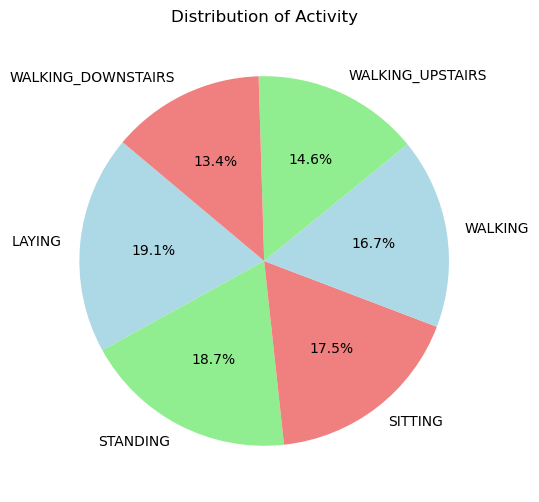

In [15]:
#Check the Target Class Imbalance

# Count occurrences of each unique label
label_counts = df['Activity'].value_counts()

# Plot the pie chart
plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightblue', 'lightgreen', 'lightcoral'])
plt.title("Distribution of Activity")
%matplotlib inline
plt.show()

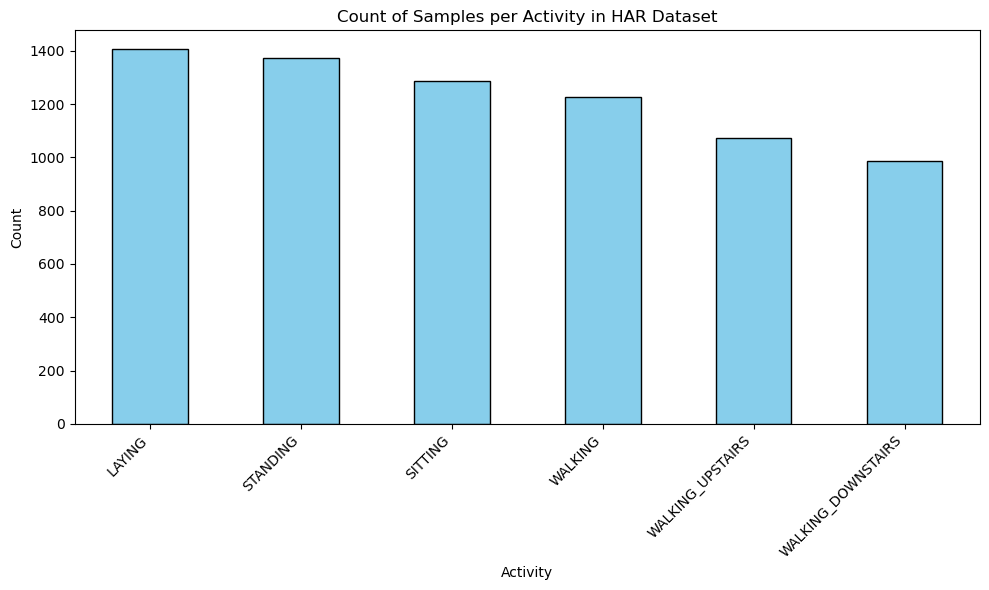

In [16]:
# Count the number of occurrences for each activity
activity_counts = df['Activity'].value_counts()

# Plot the bar chart
plt.figure(figsize=(10, 6))
activity_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Add labels and title
plt.title('Count of Samples per Activity in HAR Dataset')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.tight_layout()
plt.show()

In [17]:
X_initial = df.iloc[:,:-1]
y_initial=df.iloc[:,-1]

In [18]:
#Outliers removal based on z score

from scipy import stats
# Calculate Z-scores for each feature
z_scores = np.abs(stats.zscore(X_initial))

# Set a threshold (e.g., 3 standard deviations)
threshold = 3
outliers_z = np.where(z_scores > threshold)

# Count and print the number of outliers
print(f"Number of outliers detected by Z-Score: {len(np.unique(outliers_z[0]))}")

# Optional: Remove outliers
X_no_outliers_z = X_initial[(z_scores < threshold).all(axis=1)]
y_no_outliers_z = y_initial[(z_scores < threshold).all(axis=1)]

Number of outliers detected by Z-Score: 4553


In [19]:

# Compute correlation matrix of the columns to remove the redundant columns present
corr_matrix = X_initial.corr()
#corr_matrix = X_no_outliers_z.corr()


# its difficult to visualize correlated max having 563 columns

# Compute the correlation matrix
corr_matrix_abs = corr_matrix.abs()  # Get absolute correlation values

# Create an upper triangular mask to avoid duplicate comparisons
upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# Find columns with correlation > 0.97
to_drop = [column for column in upper.columns if any(upper[column] > 0.97)]

# Drop highly correlated columns
df_cleaned = df.drop(columns=to_drop)

print("Original DataFrame:\n", df.shape)
print("\nCorrelation Matrix:\n", corr_matrix_abs.shape)
print("\nColumns dropped:", to_drop)
print("\nCleaned DataFrame:\n", df_cleaned.shape)

Original DataFrame:
 (7352, 563)

Correlation Matrix:
 (562, 562)

Columns dropped: ['tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X', 'tBodyAcc-sma()', 'tBodyAcc-iqr()-X', 'tBodyAcc-iqr()-Y', 'tBodyAcc-iqr()-Z', 'tGravityAcc-mad()-X', 'tGravityAcc-mad()-Y', 'tGravityAcc-mad()-Z', 'tGravityAcc-max()-X', 'tGravityAcc-max()-Y', 'tGravityAcc-max()-Z', 'tGravityAcc-min()-X', 'tGravityAcc-min()-Y', 'tGravityAcc-min()-Z', 'tGravityAcc-energy()-X', 'tGravityAcc-iqr()-X', 'tGravityAcc-iqr()-Y', 'tGravityAcc-iqr()-Z', 'tGravityAcc-arCoeff()-X,2', 'tGravityAcc-arCoeff()-X,3', 'tGravityAcc-arCoeff()-X,4', 'tGravityAcc-arCoeff()-Y,2', 'tGravityAcc-arCoeff()-Y,3', 'tGravityAcc-arCoeff()-Y,4', 'tGravityAcc-arCoeff()-Z,2', 'tGravityAcc-arCoeff()-Z,3', 'tGravityAcc-arCoeff()-Z,4', 'tBodyAccJerk-std()-X', 'tBodyAccJerk-mad()-X', 'tBodyAccJerk-mad()-Y', 'tBodyAccJerk-mad()-Z', 'tBodyAccJerk-sma()', 'tBodyAccJerk-iqr()-X', 'tBodyAccJerk-iqr()-Y', 'tBodyAccJerk-iqr()-Z', 'tBo

In [20]:
#dropping column found to be highly corelated to avoid redudancy
df_test_cleaned=df_test.drop(columns=['tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X', 'tBodyAcc-sma()', 'tBodyAcc-iqr()-X', 'tBodyAcc-iqr()-Y', 'tBodyAcc-iqr()-Z', 'tGravityAcc-mad()-X', 'tGravityAcc-mad()-Y', 'tGravityAcc-mad()-Z', 'tGravityAcc-max()-X', 'tGravityAcc-max()-Y', 'tGravityAcc-max()-Z', 'tGravityAcc-min()-X', 'tGravityAcc-min()-Y', 'tGravityAcc-min()-Z', 'tGravityAcc-energy()-X', 'tGravityAcc-iqr()-X', 'tGravityAcc-iqr()-Y', 'tGravityAcc-iqr()-Z', 'tGravityAcc-arCoeff()-X,2', 'tGravityAcc-arCoeff()-X,3', 'tGravityAcc-arCoeff()-X,4', 'tGravityAcc-arCoeff()-Y,2', 'tGravityAcc-arCoeff()-Y,3', 'tGravityAcc-arCoeff()-Y,4', 'tGravityAcc-arCoeff()-Z,2', 'tGravityAcc-arCoeff()-Z,3', 'tGravityAcc-arCoeff()-Z,4', 'tBodyAccJerk-std()-X', 'tBodyAccJerk-mad()-X', 'tBodyAccJerk-mad()-Y', 'tBodyAccJerk-mad()-Z', 'tBodyAccJerk-sma()', 'tBodyAccJerk-iqr()-X', 'tBodyAccJerk-iqr()-Y', 'tBodyAccJerk-iqr()-Z', 'tBodyAccJerk-entropy()-Y', 'tBodyAccJerk-entropy()-Z', 'tBodyGyro-mad()-X', 'tBodyGyro-mad()-Y', 'tBodyGyro-mad()-Z', 'tBodyGyro-iqr()-X', 'tBodyGyro-iqr()-Y', 'tBodyGyro-iqr()-Z', 'tBodyGyroJerk-mad()-X', 'tBodyGyroJerk-mad()-Y', 'tBodyGyroJerk-mad()-Z', 'tBodyGyroJerk-max()-X', 'tBodyGyroJerk-max()-Z', 'tBodyGyroJerk-sma()', 'tBodyGyroJerk-iqr()-X', 'tBodyGyroJerk-iqr()-Y', 'tBodyGyroJerk-iqr()-Z', 'tBodyGyroJerk-entropy()-Z', 'tBodyGyroJerk-arCoeff()-Z,1', 'tBodyAccMag-mean()', 'tBodyAccMag-mad()', 'tBodyAccMag-max()', 'tBodyAccMag-sma()', 'tBodyAccMag-iqr()', 'tGravityAccMag-mean()', 'tGravityAccMag-std()', 'tGravityAccMag-mad()', 'tGravityAccMag-max()', 'tGravityAccMag-min()', 'tGravityAccMag-sma()', 'tGravityAccMag-energy()', 'tGravityAccMag-iqr()', 'tGravityAccMag-entropy()', 'tGravityAccMag-arCoeff()1', 'tGravityAccMag-arCoeff()2', 'tGravityAccMag-arCoeff()3', 'tGravityAccMag-arCoeff()4', 'tBodyAccJerkMag-mean()', 'tBodyAccJerkMag-std()', 'tBodyAccJerkMag-mad()', 'tBodyAccJerkMag-max()', 'tBodyAccJerkMag-sma()', 'tBodyAccJerkMag-energy()', 'tBodyAccJerkMag-iqr()', 'tBodyAccJerkMag-entropy()', 'tBodyGyroMag-mean()', 'tBodyGyroMag-mad()', 'tBodyGyroMag-max()', 'tBodyGyroMag-sma()', 'tBodyGyroMag-iqr()', 'tBodyGyroJerkMag-mean()', 'tBodyGyroJerkMag-std()', 'tBodyGyroJerkMag-mad()', 'tBodyGyroJerkMag-max()', 'tBodyGyroJerkMag-sma()', 'tBodyGyroJerkMag-iqr()', 'tBodyGyroJerkMag-entropy()', 'fBodyAcc-mean()-X', 'fBodyAcc-mean()-Y', 'fBodyAcc-mean()-Z', 'fBodyAcc-std()-X', 'fBodyAcc-std()-Y', 'fBodyAcc-std()-Z', 'fBodyAcc-mad()-X', 'fBodyAcc-mad()-Y', 'fBodyAcc-mad()-Z', 'fBodyAcc-max()-X', 'fBodyAcc-max()-Y', 'fBodyAcc-max()-Z', 'fBodyAcc-sma()', 'fBodyAcc-energy()-X', 'fBodyAcc-energy()-Z', 'fBodyAcc-iqr()-Z', 'fBodyAcc-entropy()-X', 'fBodyAcc-entropy()-Y', 'fBodyAcc-entropy()-Z', 'fBodyAcc-kurtosis()-X', 'fBodyAcc-kurtosis()-Y', 'fBodyAcc-kurtosis()-Z', 'fBodyAcc-bandsEnergy()-1,8', 'fBodyAcc-bandsEnergy()-1,16', 'fBodyAcc-bandsEnergy()-17,32', 'fBodyAcc-bandsEnergy()-33,48', 'fBodyAcc-bandsEnergy()-49,64', 'fBodyAcc-bandsEnergy()-1,24', 'fBodyAcc-bandsEnergy()-25,48', 'fBodyAcc-bandsEnergy()-1,16.1', 'fBodyAcc-bandsEnergy()-17,32.1', 'fBodyAcc-bandsEnergy()-33,48.1', 'fBodyAcc-bandsEnergy()-49,64.1', 'fBodyAcc-bandsEnergy()-1,24.1', 'fBodyAcc-bandsEnergy()-25,48.1', 'fBodyAcc-bandsEnergy()-1,16.2', 'fBodyAcc-bandsEnergy()-17,32.2', 'fBodyAcc-bandsEnergy()-33,48.2', 'fBodyAcc-bandsEnergy()-49,64.2', 'fBodyAcc-bandsEnergy()-1,24.2', 'fBodyAcc-bandsEnergy()-25,48.2', 'fBodyAccJerk-mean()-X', 'fBodyAccJerk-mean()-Y', 'fBodyAccJerk-mean()-Z', 'fBodyAccJerk-std()-X', 'fBodyAccJerk-std()-Y', 'fBodyAccJerk-std()-Z', 'fBodyAccJerk-mad()-X', 'fBodyAccJerk-mad()-Y', 'fBodyAccJerk-mad()-Z', 'fBodyAccJerk-max()-X', 'fBodyAccJerk-max()-Y', 'fBodyAccJerk-max()-Z', 'fBodyAccJerk-sma()', 'fBodyAccJerk-energy()-X', 'fBodyAccJerk-energy()-Y', 'fBodyAccJerk-energy()-Z', 'fBodyAccJerk-iqr()-X', 'fBodyAccJerk-iqr()-Y', 'fBodyAccJerk-iqr()-Z', 'fBodyAccJerk-entropy()-X', 'fBodyAccJerk-entropy()-Y', 'fBodyAccJerk-entropy()-Z', 'fBodyAccJerk-bandsEnergy()-1,8', 'fBodyAccJerk-bandsEnergy()-9,16', 'fBodyAccJerk-bandsEnergy()-17,24', 'fBodyAccJerk-bandsEnergy()-25,32', 'fBodyAccJerk-bandsEnergy()-17,32', 'fBodyAccJerk-bandsEnergy()-49,64', 'fBodyAccJerk-bandsEnergy()-1,24', 'fBodyAccJerk-bandsEnergy()-9,16.1', 'fBodyAccJerk-bandsEnergy()-17,24.1', 'fBodyAccJerk-bandsEnergy()-25,32.1', 'fBodyAccJerk-bandsEnergy()-1,16.1', 'fBodyAccJerk-bandsEnergy()-17,32.1', 'fBodyAccJerk-bandsEnergy()-49,64.1', 'fBodyAccJerk-bandsEnergy()-1,24.1', 'fBodyAccJerk-bandsEnergy()-25,48.1', 'fBodyAccJerk-bandsEnergy()-9,16.2', 'fBodyAccJerk-bandsEnergy()-17,24.2', 'fBodyAccJerk-bandsEnergy()-25,32.2', 'fBodyAccJerk-bandsEnergy()-33,40.2', 'fBodyAccJerk-bandsEnergy()-1,16.2', 'fBodyAccJerk-bandsEnergy()-17,32.2', 'fBodyAccJerk-bandsEnergy()-33,48.2', 'fBodyAccJerk-bandsEnergy()-49,64.2', 'fBodyAccJerk-bandsEnergy()-1,24.2', 'fBodyAccJerk-bandsEnergy()-25,48.2', 'fBodyGyro-mean()-X', 'fBodyGyro-mean()-Y', 'fBodyGyro-mean()-Z', 'fBodyGyro-std()-X', 'fBodyGyro-std()-Y', 'fBodyGyro-std()-Z', 'fBodyGyro-mad()-X', 'fBodyGyro-mad()-Y', 'fBodyGyro-mad()-Z', 'fBodyGyro-max()-X', 'fBodyGyro-max()-Z', 'fBodyGyro-sma()', 'fBodyGyro-energy()-Y', 'fBodyGyro-energy()-Z', 'fBodyGyro-entropy()-X', 'fBodyGyro-entropy()-Y', 'fBodyGyro-entropy()-Z', 'fBodyGyro-kurtosis()-X', 'fBodyGyro-kurtosis()-Y', 'fBodyGyro-kurtosis()-Z', 'fBodyGyro-bandsEnergy()-1,8', 'fBodyGyro-bandsEnergy()-1,16', 'fBodyGyro-bandsEnergy()-17,32', 'fBodyGyro-bandsEnergy()-33,48', 'fBodyGyro-bandsEnergy()-49,64', 'fBodyGyro-bandsEnergy()-1,24', 'fBodyGyro-bandsEnergy()-25,48', 'fBodyGyro-bandsEnergy()-17,32.1', 'fBodyGyro-bandsEnergy()-33,48.1', 'fBodyGyro-bandsEnergy()-49,64.1', 'fBodyGyro-bandsEnergy()-1,24.1', 'fBodyGyro-bandsEnergy()-25,48.1', 'fBodyGyro-bandsEnergy()-1,16.2', 'fBodyGyro-bandsEnergy()-17,32.2', 'fBodyGyro-bandsEnergy()-33,48.2', 'fBodyGyro-bandsEnergy()-49,64.2', 'fBodyGyro-bandsEnergy()-1,24.2', 'fBodyGyro-bandsEnergy()-25,48.2', 'fBodyAccMag-mean()', 'fBodyAccMag-std()', 'fBodyAccMag-mad()', 'fBodyAccMag-max()', 'fBodyAccMag-sma()', 'fBodyAccMag-iqr()', 'fBodyAccMag-entropy()', 'fBodyAccMag-kurtosis()', 'fBodyBodyAccJerkMag-mean()', 'fBodyBodyAccJerkMag-std()', 'fBodyBodyAccJerkMag-mad()', 'fBodyBodyAccJerkMag-max()', 'fBodyBodyAccJerkMag-sma()', 'fBodyBodyAccJerkMag-energy()', 'fBodyBodyAccJerkMag-iqr()', 'fBodyBodyAccJerkMag-entropy()', 'fBodyBodyAccJerkMag-kurtosis()', 'fBodyBodyGyroMag-mean()', 'fBodyBodyGyroMag-std()', 'fBodyBodyGyroMag-mad()', 'fBodyBodyGyroMag-max()', 'fBodyBodyGyroMag-sma()', 'fBodyBodyGyroMag-entropy()', 'fBodyBodyGyroMag-kurtosis()', 'fBodyBodyGyroJerkMag-mean()', 'fBodyBodyGyroJerkMag-std()', 'fBodyBodyGyroJerkMag-mad()', 'fBodyBodyGyroJerkMag-max()', 'fBodyBodyGyroJerkMag-sma()', 'fBodyBodyGyroJerkMag-energy()', 'fBodyBodyGyroJerkMag-iqr()', 'fBodyBodyGyroJerkMag-entropy()', 'angle(X,gravityMean)', 'angle(Y,gravityMean)', 'angle(Z,gravityMean)'])


In [21]:
df_test_cleaned.shape

(2947, 307)

In [22]:
df_test_cleaned.describe()


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-max()-Y,tBodyAcc-max()-Z,tBodyAcc-min()-X,tBodyAcc-min()-Y,...,fBodyBodyGyroJerkMag-min(),fBodyBodyGyroJerkMag-maxInds,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)",subject
count,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,...,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000
mean,0.273996,-0.017863,-0.108386,-0.613635,-0.508330,-0.633797,-0.303028,-0.574975,0.529679,0.394903,...,-0.869391,-0.902963,0.130236,-0.277593,-0.598756,0.005264,0.003799,0.040029,-0.017298,12.986427
std,0.060570,0.025745,0.042747,0.412597,0.494269,0.362699,0.274075,0.253431,0.338503,0.326645,...,0.180039,0.130682,0.231018,0.317245,0.311042,0.336147,0.445077,0.634989,0.501311,6.950984
min,-0.592004,-0.362884,-0.576184,-0.999606,-1.000000,-0.998955,-0.583487,-0.846114,-0.506816,-0.880782,...,-0.999978,-1.000000,-0.785543,-1.000000,-1.000000,-1.000000,-0.993402,-0.998898,-0.991096,2.000000
25%,0.262075,-0.024961,-0.121162,-0.990914,-0.973664,-0.976122,-0.559938,-0.810242,0.240895,0.147252,...,-0.992428,-0.968254,-0.008433,-0.517494,-0.829593,-0.130541,-0.282600,-0.518924,-0.428375,9.000000
50%,0.277113,-0.016967,-0.108458,-0.931214,-0.790972,-0.827534,-0.436526,-0.684548,0.755450,0.594357,...,-0.963172,-0.904762,0.142676,-0.311023,-0.683672,0.005188,0.006767,0.047113,-0.026726,12.000000
75%,0.288097,-0.010143,-0.097123,-0.267395,-0.105919,-0.311432,-0.075040,-0.375213,0.841741,0.683272,...,-0.798295,-0.873016,0.288320,-0.083559,-0.458332,0.146200,0.288113,0.622151,0.394387,18.000000
max,0.671887,0.246106,0.494114,0.465299,1.000000,0.489703,0.674711,0.384516,0.854911,0.707630,...,0.557422,1.000000,1.000000,1.000000,1.000000,0.998898,0.986347,1.000000,1.000000,24.000000


In [23]:
X_train = df_cleaned.iloc[:,:-1]
y_train =df_cleaned.iloc[:,-1]

X_test=df_test_cleaned.iloc[:,:-1]
y_test=df_test_cleaned.iloc[:,-1]


In [24]:
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()

# Fit and transform on X_train
#NOT USING SCALING on TRAIN DATA AS DATA IS ALREADY SCALED
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test using the same scaler
X_test_scaled = scaler.transform(X_test)



In [25]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95) 
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# Check the explained variance ratio
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance ratio: {explained_variance}")
print(f"Number of components to retain 95% variance: {pca.n_components_}")



Explained variance ratio: [0.35958865 0.07680818 0.02807185 0.02216172 0.01996806 0.01933721
 0.0166658  0.01582354 0.0119831  0.01176496 0.01109518 0.01060941
 0.01015926 0.00967816 0.00959636 0.00916228 0.00907278 0.00852482
 0.0075571  0.00726546 0.0070674  0.00690247 0.00659345 0.00651073
 0.00635701 0.00595472 0.00587902 0.0056837  0.00548823 0.00539685
 0.00513119 0.00509636 0.0050132  0.00487875 0.00465869 0.00460143
 0.00448572 0.00444402 0.00443022 0.00413671 0.00404143 0.00393715
 0.0038864  0.00380904 0.00372992 0.00362464 0.00360794 0.00347173
 0.00339674 0.0033157  0.00329795 0.00327986 0.00317734 0.00311695
 0.003095   0.00304669 0.00301959 0.00299679 0.00290725 0.0028765
 0.0028224  0.00277089 0.00272218 0.0027041  0.00263386 0.00257762
 0.00252458 0.00251414 0.00244729 0.00242441 0.00237791 0.00229136
 0.00225752 0.00225355 0.00215782 0.00212306 0.00210092 0.00204484
 0.00203119 0.00199423 0.00193537 0.00192764 0.00188408 0.00179543
 0.00176642 0.00175124 0.00167961 0.0

In [26]:
X_train_pca.shape

(7352, 117)

In [27]:
X_test_pca.shape

(2947, 117)

In [28]:
###outliers code

In [65]:
# Save PCA and selected columns
joblib.dump(pca, 'pca_transformer.pkl')
joblib.dump(df_cleaned.columns, 'selected_columns.pkl')

['selected_columns.pkl']

In [29]:
X_no_outliers_z.shape

(2799, 562)

In [30]:
y_no_outliers_z.shape

(2799,)

In [31]:
# assigning proper columns to train dataset 
#X_train = X_no_outliers_z
#y_train= y_no_outliers_z

X_train = X_train_pca
y_train= y_train

#X_train = X_no_outliers_z
#y_train= y_no_outliers_z

X_test=X_test_pca
y_test=y_test

In [32]:
X_train.shape

(7352, 117)

In [33]:
y_train.shape

(7352,)

In [34]:
X_test.shape

(2947, 117)

In [35]:
from sklearn import svm
# import metrics to compute accuracy
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [36]:
from sklearn.linear_model import LogisticRegression
# Create and train the Logistic Regression model
logisticregressionmodel = LogisticRegression(max_iter=1000)
logisticregressionmodel.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [37]:
# Make predictions
y_pred = logisticregressionmodel.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Model Accuracy: {accuracy:.2f}")
print("\n Logistic Regression Model Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Model Accuracy: 0.94

 Logistic Regression Model Classification Report:
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.94      0.88      0.91       491
          STANDING       0.90      0.94      0.92       532
           WALKING       0.92      0.97      0.94       496
WALKING_DOWNSTAIRS       0.95      0.90      0.93       420
  WALKING_UPSTAIRS       0.92      0.92      0.92       471

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



In [38]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],  # Regularization strength
    'solver': ['lbfgs', 'saga'],     # Solvers for optimization
    'max_iter': [500, 1000, 2000]    # Number of iterations
}

# Create the GridSearchCV object
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy', verbose=1)


# Fit grid search
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.2f}")

# Use the best estimator to make predictions
best_model_lg = grid_search.best_estimator_
y_pred_best = best_model_lg.predict(X_test_scaled)

# Evaluate the tuned model
print(classification_report(y_test, y_pred_best))
print(f"Tuned Model Accuracy: {accuracy_score(y_test, y_pred_best):.2f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max

Best Parameters: {'C': 1, 'max_iter': 500, 'solver': 'lbfgs'}
Best Cross-Validation Score: 0.93
                    precision    recall  f1-score   support

            LAYING       1.00      0.99      1.00       537
           SITTING       0.96      0.86      0.90       491
          STANDING       0.88      0.97      0.92       532
           WALKING       0.93      0.99      0.96       496
WALKING_DOWNSTAIRS       0.99      0.95      0.97       420
  WALKING_UPSTAIRS       0.96      0.93      0.95       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947

Tuned Model Accuracy: 0.95


In [43]:
import joblib
# Save the trained model to a file
joblib.dump(best_model_lg, 'logistic_model.pkl')

# Save the scaler to ensure consistent data transformation
joblib.dump(scaler, 'scaler.pkl')




['scaler.pkl']

In [44]:
svc_linear = svm.SVC(kernel='linear')
svc_linear.fit(X_train, y_train)
# make predictions on test set
y_pred=svc_linear.predict(X_test)
# compute and print accuracy score
print('SVC Linear: Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))
print("\nClassification Report:\n\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print('\n\nConfusion matrix\n\n', cm)

SVC Linear: Model accuracy score with default hyperparameters: 0.9182

Classification Report:

                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.93      0.86      0.89       491
          STANDING       0.88      0.94      0.91       532
           WALKING       0.88      0.95      0.92       496
WALKING_DOWNSTAIRS       0.92      0.87      0.90       420
  WALKING_UPSTAIRS       0.90      0.87      0.88       471

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



Confusion matrix

 [[537   0   0   0   0   0]
 [  1 421  68   0   0   1]
 [  0  31 501   0   0   0]
 [  0   0   0 472  17   7]
 [  0   0   0  15 365  40]
 [  0   0   0  48  13 410]]


In [45]:
svc_poly = svm.SVC(kernel='poly')
svc_poly.fit(X_train, y_train)
# make predictions on test set
y_pred=svc_poly.predict(X_test)
# compute and print accuracy score
print('SVC poly: Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))
print("\nClassification Report:\n\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print('\n\nConfusion matrix\n\n', cm)

SVC poly: Model accuracy score with default hyperparameters: 0.9175

Classification Report:

                     precision    recall  f1-score   support

            LAYING       1.00      0.98      0.99       537
           SITTING       0.92      0.87      0.89       491
          STANDING       0.89      0.95      0.92       532
           WALKING       0.85      0.99      0.91       496
WALKING_DOWNSTAIRS       0.98      0.78      0.87       420
  WALKING_UPSTAIRS       0.90      0.92      0.91       471

          accuracy                           0.92      2947
         macro avg       0.92      0.91      0.91      2947
      weighted avg       0.92      0.92      0.92      2947



Confusion matrix

 [[525  10   2   0   0   0]
 [  1 427  60   0   0   3]
 [  0  27 504   1   0   0]
 [  0   0   0 489   4   3]
 [  0   0   0  50 328  42]
 [  0   0   0  37   3 431]]


In [46]:
svc_rbf = svm.SVC(kernel='rbf')
svc_rbf.fit(X_train, y_train)
# make predictions on test set
y_pred=svc_rbf.predict(X_test)
# compute and print accuracy score
print('SVC RBF: Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

print("\nClassification Report:\n\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print('\n\nConfusion matrix\n\n', cm)

SVC RBF: Model accuracy score with default hyperparameters: 0.9437

Classification Report:

                     precision    recall  f1-score   support

            LAYING       0.99      1.00      1.00       537
           SITTING       0.93      0.89      0.91       491
          STANDING       0.91      0.94      0.92       532
           WALKING       0.95      0.97      0.96       496
WALKING_DOWNSTAIRS       0.97      0.90      0.94       420
  WALKING_UPSTAIRS       0.92      0.95      0.93       471

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



Confusion matrix

 [[537   0   0   0   0   0]
 [  3 435  52   0   0   1]
 [  0  32 500   0   0   0]
 [  0   0   0 482   6   8]
 [  0   0   0   9 380  31]
 [  0   0   0  18   6 447]]


In [59]:
# Save the model to a .pkl file
joblib.dump(svc_rbf, 'svc_rbf_model.pkl')


['svc_rbf_model.pkl']

In [47]:
# Define hyperparameters to tune
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 1, 10],
    'degree': [2, 3, 4]  # Only relevant for 'poly' kernel
}

# Create SVC model
svc = svm.SVC()

# Apply GridSearchCV
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Accuracy: {grid_search.best_score_:.4f}")

# Evaluate on test data
best_model_svc = grid_search.best_estimator_
y_pred = best_model_svc.predict(X_test)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best Accuracy: 0.9193
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.93      0.87      0.90       491
          STANDING       0.89      0.94      0.91       532
           WALKING       0.89      0.95      0.92       496
WALKING_DOWNSTAIRS       0.92      0.87      0.90       420
  WALKING_UPSTAIRS       0.90      0.87      0.89       471

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



In [48]:
from sklearn.preprocessing import LabelEncoder
# Encode target labels (Convert categorical to numeric)
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.fit_transform(y_test)

In [49]:
import xgboost as xgb

# Create DMatrix for XGBoost (efficient training format)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set XGBoost parameters
params = {
    'objective': 'multi:softmax',  # Multiclass classification
    'num_class': len(set(y_train)),  # Number of classes
    'eval_metric': 'mlogloss',  # Log loss for multiclass classification
    'max_depth': 6,  # Maximum depth of a tree
    'eta': 0.1,  # Learning rate
    'gamma': 0.1,  # Minimum loss reduction required for split
}

# Train the XGBoost model
num_rounds = 100  # Number of boosting rounds
xgbmodel = xgb.train(params, dtrain, num_boost_round=num_rounds)
print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [50]:
# Make predictions
y_pred = xgbmodel.predict(dtest)

# Evaluate model 
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

XGBoost Model Accuracy: 0.8863

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.96       537
           1       0.87      0.80      0.83       491
           2       0.84      0.92      0.87       532
           3       0.84      0.97      0.90       496
           4       0.90      0.77      0.83       420
           5       0.91      0.88      0.89       471

    accuracy                           0.89      2947
   macro avg       0.89      0.88      0.88      2947
weighted avg       0.89      0.89      0.89      2947



In [60]:

# Save the model to a .pkl file
joblib.dump(xgbmodel, 'xgbmodel.pkl')

['xgbmodel.pkl']

In [51]:
"""
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [0.5, 1, 2]
}

# Initialize XGBoost
xgb_model = xgb.XGBClassifier(eval_metric='logloss')

# Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, 
                           cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Best parameters
print(f"Best Parameters: {grid_search.best_params_}")

# Use best model from GridSearchCV
best_model_xgboost = grid_search.best_estimator_

# Make predictions
y_pred_best = best_model_xgboost.predict(X_test)

# Evaluate performance
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Tuned Model Accuracy: {accuracy_best:.4f}")

"""

'\n# Define parameter grid\nparam_grid = {\n    \'n_estimators\': [100, 200, 300],\n    \'max_depth\': [3, 5, 7],\n    \'learning_rate\': [0.01, 0.1, 0.2],\n    \'subsample\': [0.7, 0.8, 1.0],\n    \'colsample_bytree\': [0.7, 0.8, 1.0],\n    \'gamma\': [0, 0.1, 0.2],\n    \'reg_alpha\': [0, 0.01, 0.1],\n    \'reg_lambda\': [0.5, 1, 2]\n}\n\n# Initialize XGBoost\nxgb_model = xgb.XGBClassifier(eval_metric=\'logloss\')\n\n# Grid Search with 5-fold cross-validation\ngrid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, \n                           cv=5, scoring=\'accuracy\', n_jobs=-1, verbose=1)\n\n# Fit GridSearchCV\ngrid_search.fit(X_train, y_train)\n\n# Best parameters\nprint(f"Best Parameters: {grid_search.best_params_}")\n\n# Use best model from GridSearchCV\nbest_model_xgboost = grid_search.best_estimator_\n\n# Make predictions\ny_pred_best = best_model_xgboost.predict(X_test)\n\n# Evaluate performance\naccuracy_best = accuracy_score(y_test, y_pred_best)\nprint(f"Tu

In [52]:
from sklearn.ensemble import RandomForestClassifier
# Create and train the Random Forest model
randomforestmodel = RandomForestClassifier(n_estimators=100, random_state=42)
randomforestmodel.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [53]:
# Make predictions
y_pred = randomforestmodel.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f" Random Forest Model Accuracy: {accuracy:.2f}")
print("\n Random Forest Model Classification Report:")
print(classification_report(y_test, y_pred))

 Random Forest Model Accuracy: 0.88

 Random Forest Model Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       537
           1       0.86      0.77      0.81       491
           2       0.82      0.90      0.86       532
           3       0.84      0.95      0.89       496
           4       0.87      0.76      0.82       420
           5       0.91      0.89      0.90       471

    accuracy                           0.88      2947
   macro avg       0.88      0.87      0.87      2947
weighted avg       0.88      0.88      0.87      2947



In [61]:
# Save the model to a .pkl file
joblib.dump(randomforestmodel, 'randomforestmodel.pkl')

['randomforestmodel.pkl']

In [54]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [55]:
#Now lets apply the deep learning Model 

# Define model architecture
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(len(np.unique(y_train)), activation='softmax')  # Softmax for multi-class classification
])

# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()


/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-03-30 09:11:56.941152: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-03-30 09:11:56.941213: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-03-30 09:11:56.941223: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-03-30 09:11:56.941491: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-30 09:11:56.941517: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorF

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         3,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,406 (17.21 KB)

 Trainable params: 4,406 (17.21 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50


2025-03-30 09:11:57.540111: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


919/919 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5160 - loss: 1.7146 - val_accuracy: 0.9162 - val_loss: 0.2502
Epoch 2/50
919/919 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8525 - loss: 0.3861 - val_accuracy: 0.9287 - val_loss: 0.1860
Epoch 3/50
919/919 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9099 - loss: 0.2242 - val_accuracy: 0.9325 - val_loss: 0.1745
Epoch 4/50
919/919 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9303 - loss: 0.1768 - val_accuracy: 0.9257 - val_loss: 0.1940
Epoch 5/50
919/919 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9465 - loss: 0.1538 - val_accuracy: 0.9230 - val_loss: 0.1941
Epoch 6/50
919/919 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9435 - loss: 0.1361 - val_accuracy: 0.9213 - val_loss: 0.2077
Epoch 7/50
919/919 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9465 - loss: 0.1418 - val_accuracy: 0.9274 - val_loss: 0.1945
Epoch 8/50
919/919 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9530 - loss: 0.1185 - val_accuracy: 0.9192 - val_

In [57]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9177 - loss: 0.2758
Test Accuracy: 0.9203


In [58]:
# Predict class labels
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

print("Predicted Classes:", encoder.inverse_transform(predicted_classes[:10]))
print("Actual Classes:", encoder.inverse_transform(y_test[:10]))

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Predicted Classes: ['STANDING' 'STANDING' 'STANDING' 'STANDING' 'STANDING' 'STANDING'
 'STANDING' 'STANDING' 'SITTING' 'STANDING']
Actual Classes: ['STANDING' 'STANDING' 'STANDING' 'STANDING' 'STANDING' 'STANDING'
 'STANDING' 'STANDING' 'STANDING' 'STANDING']


In [ ]:
#!pip install scikeras

In [62]:
# Save the model to a .pkl file
joblib.dump(model, 'ann_model.pkl')

['ann_model.pkl']